## THIN FILE LOAN AWARDING SYSTEM

## Imports

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 5]

pd.set_option('display.max_columns', 50)


## EDA

In [6]:
df = pd.read_csv('data/thin_file_credit_data.csv')
df.head()

,user_id,device_age_days,sim_swap_count_3m,avg_monthly_inflow,inflow_volatility,utility_bill_payment_ratio,airtime_topup_freq_pm,avg_airtime_topup_val,default_within_30_days
0,user_100000,132,0,14906.14,0.318,0.755,17,89.75,0
1,user_100001,465,0,7707.18,0.740,0.581,13,80.04,0
2,user_100002,890,0,2678.16,0.734,0.928,21,46.93,0
3,user_100003,300,0,12614.38,0.629,0.584,17,25.10,0
4,user_100004,136,0,5341.46,0.066,0.592,9,114.63,0


In [9]:
# Map the target variable to string for clearer legends in plots
df['repayment_status'] = df['default_within_30_days'].map({0: 'Repaid', 1: 'Defaulted'})

In [10]:
df.head()

,user_id,device_age_days,sim_swap_count_3m,avg_monthly_inflow,inflow_volatility,utility_bill_payment_ratio,airtime_topup_freq_pm,avg_airtime_topup_val,default_within_30_days,repayment_status
0,user_100000,132,0,14906.14,0.318,0.755,17,89.75,0,Repaid
1,user_100001,465,0,7707.18,0.740,0.581,13,80.04,0,Repaid
2,user_100002,890,0,2678.16,0.734,0.928,21,46.93,0,Repaid
3,user_100003,300,0,12614.38,0.629,0.584,17,25.10,0,Repaid
4,user_100004,136,0,5341.46,0.066,0.592,9,114.63,0,Repaid


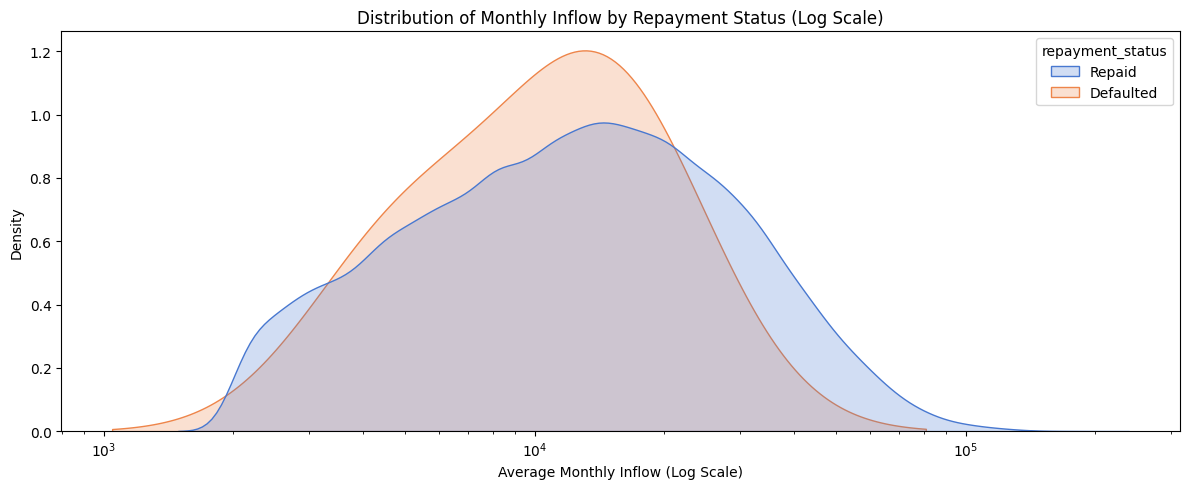

In [12]:
# Plot of Income Skew and Risk Separation 
plt.figure(figsize=(12, 5))
sns.kdeplot(
    data=df, 
    x='avg_monthly_inflow', 
    hue='repayment_status', 
    fill=True, 
    common_norm=False, 
    palette='muted', 
    log_scale=True
)
plt.title('Distribution of Monthly Inflow by Repayment Status (Log Scale)')
plt.xlabel('Average Monthly Inflow (Log Scale)')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

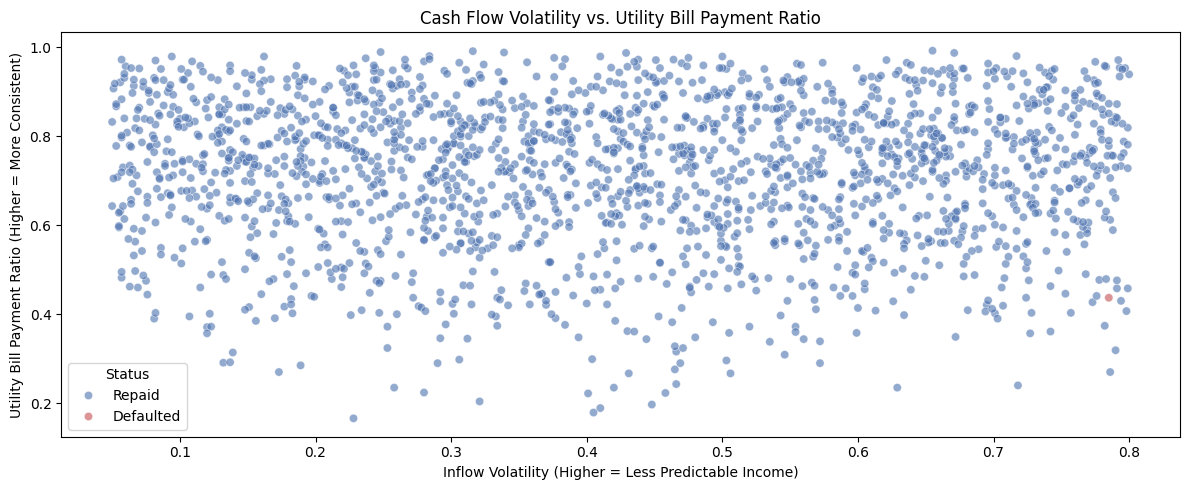

In [15]:
# Behavioral Interraction vs Risk
plt.figure(figsize=(12, 5))
sns.scatterplot(
    data=df.sample(2000, random_state=42),
    x='inflow_volatility',
    y='utility_bill_payment_ratio',
    hue='repayment_status',
    alpha=0.6,
    palette={'Repaid': '#4c72b0', 'Defaulted': '#c44e52'}   
)
plt.title("Cash Flow Volatility vs. Utility Bill Payment Ratio")
plt.xlabel("Inflow Volatility (Higher = Less Predictable Income)")
plt.ylabel("Utility Bill Payment Ratio (Higher = More Consistent)")
plt.legend(title="Status")
plt.tight_layout()
plt.savefig("eda_behavioral_interaction.png")
plt.show()

## Feature Engineering

In [21]:
def feature_engineering(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Perform feature engineering on the credit data.

    Parameters:
    df (pd.DataFrame): The input DataFrame containing credit data.

    Returns:
    pd.DataFrame: The DataFrame with new features added.
    """
    df_engineered = dataframe.copy()
    
    # 1. Telco liquidity proxies
    df_engineered['airtime_unit_value'] = df_engineered['avg_airtime_topup_val'] / (df_engineered['airtime_topup_freq_pm'] + 1)
    df_engineered['total_airtime_spend'] = df_engineered['airtime_topup_freq_pm'] * df_engineered['avg_airtime_topup_val']
    df_engineered['inflow_to_airtime_ratio'] = df_engineered['avg_monthly_inflow'] / (df_engineered['total_airtime_spend'] + 1)
    
    # 2. Volatility indexing
    df_engineered['risk_adjusted_inflow'] = df_engineered['avg_monthly_inflow'] * (1.0 - df_engineered['inflow_volatility'])
    
    # 3. Identity stability tracking
    df_engineered['device_stability_index'] = (df_engineered['device_age_days'] / 365.0) / (df_engineered['sim_swap_count_3m'] + 1)

    return df_engineered

In [22]:
modified_df = feature_engineering(df)
modified_df.head()

,user_id,device_age_days,sim_swap_count_3m,avg_monthly_inflow,inflow_volatility,utility_bill_payment_ratio,airtime_topup_freq_pm,avg_airtime_topup_val,default_within_30_days,repayment_status,airtime_unit_value,total_airtime_spend,inflow_to_airtime_ratio,risk_adjusted_inflow,device_stability_index
0,user_100000,132,0,14906.14,0.318,0.755,17,89.75,0,Repaid,4.986111,1525.75,9.763314,10165.98748,0.361644
1,user_100001,465,0,7707.18,0.740,0.581,13,80.04,0,Repaid,5.717143,1040.52,7.399935,2003.86680,1.273973
2,user_100002,890,0,2678.16,0.734,0.928,21,46.93,0,Repaid,2.133182,985.53,2.714727,712.39056,2.438356
3,user_100003,300,0,12614.38,0.629,0.584,17,25.10,0,Repaid,1.394444,426.70,29.493523,4679.93498,0.821918
4,user_100004,136,0,5341.46,0.066,0.592,9,114.63,0,Repaid,11.463000,1031.67,5.172475,4988.92364,0.372603
